# Notebook 1 – California Housing (Regression)

## Overview
We benchmark six tabular-learning methods on the California Housing dataset:
**Tabular ResNet**, **FT-Transformer**, **XGBoost**, **LightGBM**, **Random Forest** and **Ridge Regression**.  
Each model is tuned with **Optuna** (20 trials) and evaluated across 3 seeds.  
Metrics: **RMSE**, **MAE**, **R²**.


## Imports

In [115]:
import warnings
warnings.filterwarnings('ignore')

import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import rtdl_revisiting_models
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import time
import io
from pytorch_tabnet.tab_model import TabNetRegressor
from rtdl_revisiting_models import ResNet
from rtdl_revisiting_models import FTTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## Configuration
These parameters denote the key parameters for the experiments.
- SEEDS: Set 3 specific seed numbers
- N_OPTUNA_TRIALS: Number of trials to run for Optuna hyperparameter tuning
- TEST_SIZE: Proportion of data used for train-test split
- VAL_FRAC: Proportion of training data divided into train-validation (effectively 60/20/20 for train/val/test split)
- N_PATIENCE: Number of trials for early stopping when validation performance stops improving
- OPT_EPOCHS: Number of epochs to run for Optuna hyperparameter tuning
- TR_EPOCHS: Number of epochs to run when training across seeds
- N_BATCH_SIZE: Number of mini-batches used when training neural network models

In [116]:
SEEDS          = [42, 123, 456]
N_OPTUNA_TRIALS = 20
TEST_SIZE       = 0.20
VAL_FRAC        = 0.25 
N_PATIENCE      = 10
OPT_EPOCHS      = 50
TR_EPOCHS       = 100
N_BATCH_SIZE    = 1024


## Data Loading & EDA
- Load dataset from scikit-learn.
- Inspect shape and data types. Generate statistical summary and check for missing values.

In [117]:
data = fetch_california_housing(as_frame=True)
df   = data.frame

print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print(df.describe())
print()
print("Missing values:")
print(df.isnull().sum())

# No missing values. All features are numeric.

Shape: (20640, 9)

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude

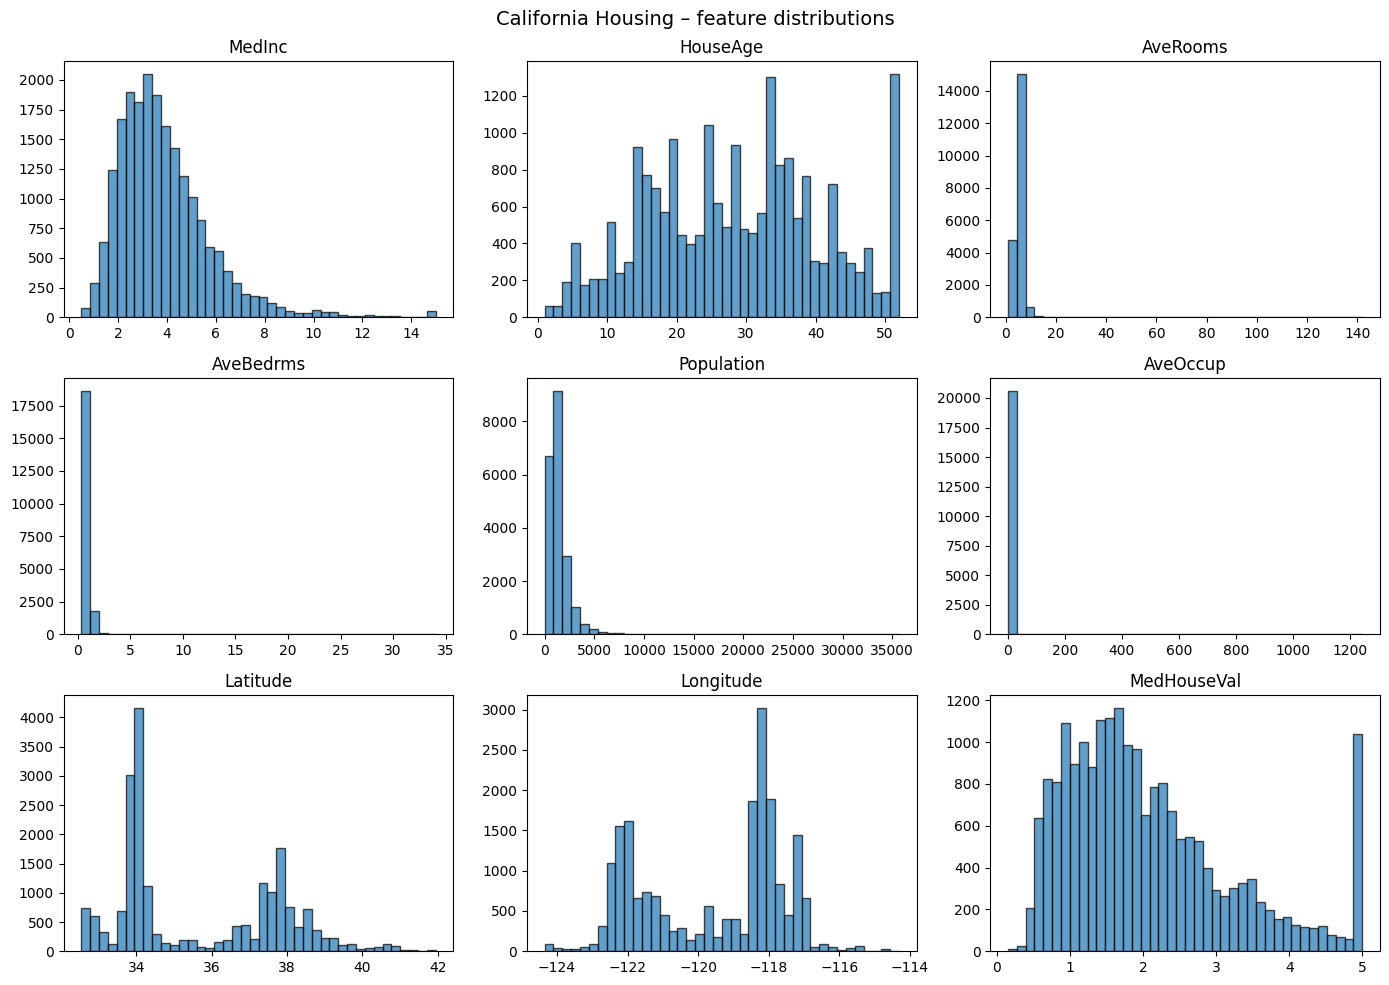

In [118]:
# Plot bar plots of all features to see their distributions and scales.
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=40, edgecolor='k', alpha=0.7)
    axes[i].set_title(col)
plt.suptitle("California Housing – feature distributions", fontsize=14)
plt.tight_layout()
plt.show()

# The features have very different scales and skew. Some features have heavy-tailed distributions (e.g. Population, AveOccup, AveRooms)

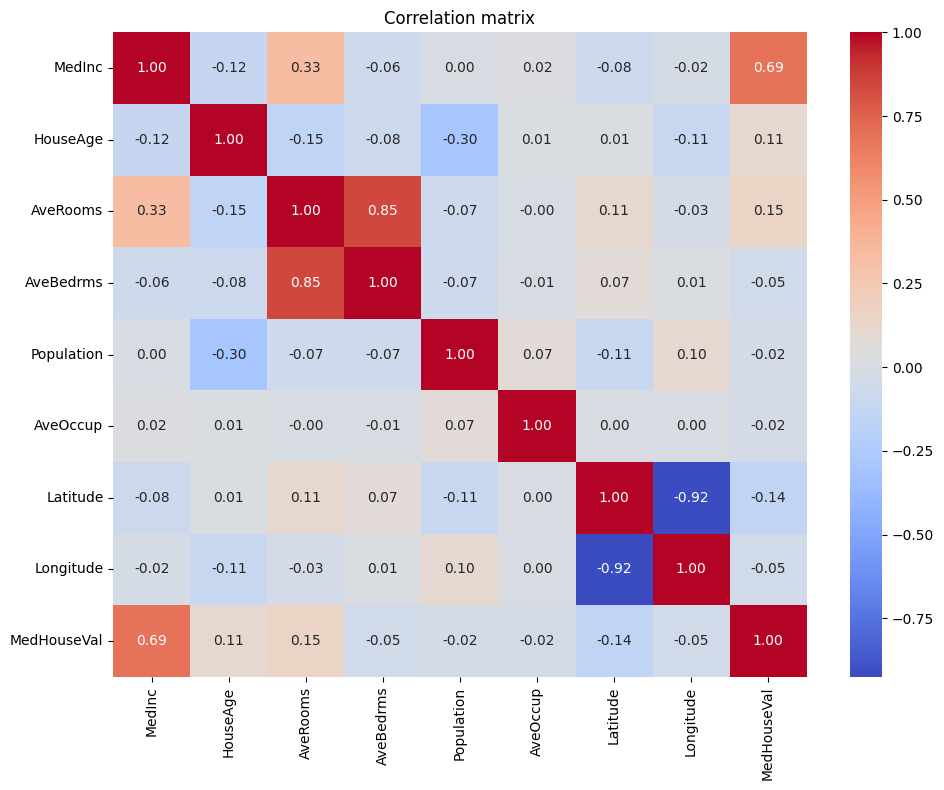

In [119]:
# Plot correlation matrix to see relationships between features and target.
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


## Preprocessing
- Extract features and target from dataset

In [120]:
feature_cols = [c for c in df.columns if c != 'MedHouseVal']
target_col   = 'MedHouseVal'

X = df[feature_cols].values.astype(np.float32)
y = df[target_col].values.astype(np.float32)


## Data Splitting (60 / 20 / 20)
- Split data into training, validation and test sets.
- Standardise features using StandardScaler for Deep Learning and Ridge regression models.

In [121]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_FRAC, random_state=42)

# Standardize features (zero mean, unit variance) for Deep Learning and Ridge regression models.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {X_train_sc.shape}, Val: {X_val_sc.shape}, Test: {X_test_sc.shape}")

Train: (12384, 8), Val: (4128, 8), Test: (4128, 8)


## Helper Functions
- Set random seeds for reproducibility across NumPy, PyTorch, and CUDA.
- Define regression metrics: RMSE, MAE and Rsquared
- Implement generic training and prediction functions for deep learning models.
- Define PhaseTimer object to record modelling time.

In [122]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def compute_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2


def train_ft_transformer(model, X_num_tr, X_cat_tr, y_tr,
                          X_num_v, X_cat_v, y_v,
                          lr=1e-3, n_epochs=TR_EPOCHS, batch_size=N_BATCH_SIZE,
                          task='regression', device_='cpu'):
    model = model.to(device_)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss() if task == 'regression' else nn.BCEWithLogitsLoss()

    X_num_tr_t = torch.FloatTensor(X_num_tr).to(device_)
    X_cat_tr_t = torch.LongTensor(X_cat_tr).to(device_) if X_cat_tr is not None else None
    y_tr_t     = torch.FloatTensor(y_tr).to(device_)
    X_num_v_t  = torch.FloatTensor(X_num_v).to(device_)
    X_cat_v_t  = torch.LongTensor(X_cat_v).to(device_) if X_cat_v is not None else None
    y_v_t      = torch.FloatTensor(y_v).to(device_)

    train_losses, val_losses = [], []
    best_val  = float('inf')
    best_state = None
    patience  = N_PATIENCE
    pat_cnt   = 0

    for epoch in range(n_epochs):
        model.train()
        n   = len(X_num_tr_t)
        idx = torch.randperm(n)
        ep_loss = 0.0
        for i in range(0, n, batch_size):
            b  = idx[i:i+batch_size]
            xn = X_num_tr_t[b]
            xc = X_cat_tr_t[b] if X_cat_tr_t is not None else None
            yb = y_tr_t[b]
            optimizer.zero_grad()
            out  = model(xn, xc).squeeze(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item() * len(b)
        model.eval()
        with torch.no_grad():
            vout  = model(X_num_v_t, X_cat_v_t).squeeze(-1)
            vloss = criterion(vout, y_v_t).item()
        train_losses.append(ep_loss / n)
        val_losses.append(vloss)
        if vloss < best_val:
            best_val   = vloss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            pat_cnt    = 0
        else:
            pat_cnt += 1
        if pat_cnt >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses


def predict_ft_transformer(model, X_num, X_cat, device_, batch_size=N_BATCH_SIZE):
    model.eval()
    model    = model.to(device_)
    X_num_t  = torch.FloatTensor(X_num).to(device_)
    X_cat_t  = torch.LongTensor(X_cat).to(device_) if X_cat is not None else None
    preds    = []
    with torch.no_grad():
        for i in range(0, len(X_num_t), batch_size):
            xn  = X_num_t[i:i+batch_size]
            xc  = X_cat_t[i:i+batch_size] if X_cat_t is not None else None
            out = model(xn, xc).squeeze(-1)
            preds.append(out.cpu().numpy())
    return np.concatenate(preds)

class PhaseTimer:
    def __init__(self):
        self._totals = {}
        self._counts = {}
        self._start = {}

    def start(self, phase):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        self._start[phase] = time.perf_counter()

    def stop(self, phase):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - self._start[phase]
        self._totals[phase] = self._totals.get(phase, 0.0) + elapsed
        self._counts[phase] = self._counts.get(phase, 0) + 1

    def get_total(self, phase):
        return self._totals.get(phase, 0.0)

    def reset(self):
        self._totals.clear()
        self._counts.clear()
        self._start.clear()

    def report(self, label=''):
        total = sum(self._totals.values())
        print(f"\n--- Bottleneck Report {label} ---")
        for k, v in sorted(self._totals.items(), key=lambda x: -x[1]):
            pct = 100 * v / total if total > 0 else 0.0
            avg = 1000 * v / self._counts[k]
            print(f"{k:<20} {v:.3f}s ({pct:.1f}%) avg {avg:.2f} ms")
        print(f"TOTAL: {total:.3f}s\n")


In [123]:
# Instantiate key variables for results and timing
all_results    = []
timing_results = []

# Initialize the phase timer for measuring training and inference times
timer = PhaseTimer()

# Model Training
2 Deep Learning models and 4 Classical Baseline models are trained to evaluate their comparative performance. The following steps are carried out equally for each experiment to ensure fairness as much as possible:
1. An Optuna tuning step is performed for hyperparameter tuning to find the best set of hyperparameters.
2. At each step, models are training using the training set and evaluated on the validation set to return the RMSE score.
3. The Optuna trial with the best RMSE score defines the best set of hyperparameters.
4. The models are trained with different seeds to evaluate the impact of randomness on model variability.
5. Statistics on scoring metrics, latency and model size are collected for subsequent analysis.

## Model 1: Tabular ResNet

In [124]:
n_num = X_train_sc.shape[1]

def train_resnet(
    model, X_tr, y_tr,
    X_v, y_v,
    lr=1e-3, n_epochs=TR_EPOCHS, batch_size=N_BATCH_SIZE,
    device_='cpu'
):
    model = model.to(device_)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    X_tr_t = torch.FloatTensor(X_tr).to(device_)
    y_tr_t = torch.FloatTensor(y_tr).to(device_)
    X_v_t  = torch.FloatTensor(X_v).to(device_)
    y_v_t  = torch.FloatTensor(y_v).to(device_)

    train_losses, val_losses = [], []
    best_val = float('inf')
    best_state = None
    patience = N_PATIENCE
    pat_cnt = 0

    for epoch in range(n_epochs):
        model.train()
        n = len(X_tr_t)
        idx = torch.randperm(n)

        ep_loss = 0.0
        for i in range(0, n, batch_size):
            b = idx[i:i + batch_size]
            xb = X_tr_t[b]
            yb = y_tr_t[b]

            optimizer.zero_grad()
            out = model(xb).squeeze(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            ep_loss += loss.item() * len(b)

        model.eval()
        with torch.no_grad():
            vout  = model(X_v_t).squeeze(-1)
            vloss = criterion(vout, y_v_t).item()

        train_losses.append(ep_loss / n)
        val_losses.append(vloss)

        if vloss < best_val:
            best_val = vloss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            pat_cnt = 0
        else:
            pat_cnt += 1

        if pat_cnt >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses

def predict_resnet(model, X, device_, batch_size=512):
    model.eval()
    model = model.to(device_)
    X_t = torch.FloatTensor(X).to(device_)
    preds = []

    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            xb = X_t[i:i + batch_size]
            out = model(xb).squeeze(-1)
            preds.append(out.cpu().numpy())

    return np.concatenate(preds)

In [125]:
# Optuna objective function for TabularResNet hyperparameter tuning
def resnet_reg_objective(trial):
    print(f"\nTrial {trial.number + 1}/{N_OPTUNA_TRIALS}")

    d_block = trial.suggest_categorical("d_block", [128, 256])
    n_blocks = trial.suggest_int("n_blocks", 2, 6)
    dropout1 = trial.suggest_float("dropout1", 0.0, 0.3)
    dropout2 = trial.suggest_float("dropout2", 0.0, 0.3)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)

    set_seed(42)

    model = ResNet(
        d_in=n_num,
        d_out=1,
        n_blocks=n_blocks,
        d_block=d_block,
        d_hidden=None,                    
        d_hidden_multiplier=4 / 3,       
        dropout1=dropout1,
        dropout2=dropout2,
    )

    model, _, _ = train_resnet(
        model,
       X_train_sc, y_train,
        X_val_sc,   y_val,
        lr=lr,
        n_epochs=OPT_EPOCHS,
        batch_size=N_BATCH_SIZE,
        device_=str(device),
    )

    preds = predict_resnet(model, X_val_sc, str(device))
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

timer.start("optuna")

study_resnet = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_resnet.optimize(resnet_reg_objective, n_trials=N_OPTUNA_TRIALS)

timer.stop("optuna")

best_resnet = study_resnet.best_params
print("Best ResNet params:", best_resnet)


Trial 1/20

Trial 2/20

Trial 3/20

Trial 4/20

Trial 5/20

Trial 6/20

Trial 7/20

Trial 8/20

Trial 9/20

Trial 10/20

Trial 11/20

Trial 12/20

Trial 13/20

Trial 14/20

Trial 15/20

Trial 16/20

Trial 17/20

Trial 18/20

Trial 19/20

Trial 20/20
Best ResNet params: {'d_block': 128, 'n_blocks': 3, 'dropout1': 0.17359548546516695, 'dropout2': 0.1472473670473546, 'lr': 0.0019116011102780807}


In [126]:
# Train TabularResNet across multiple seeds using the best hyperparameters found by Optuna
print("Training Tabular ResNet across seeds...")
resnet_train_curves = {}

for seed in SEEDS:
    set_seed(seed)

    model = ResNet(
        d_in=n_num,
        d_out=1,
        n_blocks=best_resnet["n_blocks"],
        d_block=best_resnet["d_block"],
        d_hidden=None,
        d_hidden_multiplier=4 / 3,
        dropout1=best_resnet["dropout1"],
        dropout2=best_resnet["dropout2"],
    )

    timer.start("train")
    model, tr_l, va_l = train_resnet(
        model,
        X_train_sc, y_train,
        X_val_sc, y_val,
        lr=best_resnet["lr"],
        n_epochs=TR_EPOCHS,
        batch_size=N_BATCH_SIZE,
        device_=str(device),)

    timer.stop("train")

    resnet_train_curves[seed] = (tr_l, va_l)

    timer.start("inference")
    preds = predict_resnet(model, X_test_sc, str(device))
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_sc)

    rmse, mae, r2 = compute_regression_metrics(y_test, preds)

    all_results.append({
        "method": "Tabular ResNet",
        "seed": seed,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,})

    rn_model_last = model
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")
    

Training Tabular ResNet across seeds...
  Seed 42: RMSE=0.5431, MAE=0.3606, R2=0.7749
  Seed 123: RMSE=0.5458, MAE=0.3662, R2=0.7727
  Seed 456: RMSE=0.5548, MAE=0.3714, R2=0.7652


In [127]:
# Tabular ResNet Model Size
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
size_mb = len(buffer.getvalue()) / (1024 ** 2)

num_params = sum(p.numel() for p in model.parameters())

print(f"Tabular ResNet model size: {size_mb:.2f} MB")

Tabular ResNet model size: 0.53 MB


In [128]:
# TabularResNet Timing Report
optuna_time = timer.get_total("optuna")
train_time     = timer.get_total("train")
inference_time = timer.get_total("inference")

timing_results.append({
    "method":         "TabularResNet",
    "optuna_time":    optuna_time,
    "train_time":     train_time,
    "inference_time": inference_time,
})
timer.report("TabularResNet")



--- Bottleneck Report TabularResNet ---
optuna               628.004s (90.4%) avg 628003.73 ms
train                66.452s (9.6%) avg 22150.72 ms
inference            0.061s (0.0%) avg 20.22 ms
TOTAL: 694.517s



## Model 2: FT-Transformer

In [129]:
# Optuna objective function for FT-Transformer hyperparameter tuning
n_num = X_train_sc.shape[1]

def ft_reg_objective(trial):
    print(f"\nTrial {trial.number + 1}/{N_OPTUNA_TRIALS}")
    d_block = trial.suggest_categorical('d_block', [64, 128])
    n_blocks = trial.suggest_int('n_blocks', 1, 3)
    attn_drop = trial.suggest_float('attention_dropout', 0.0, 0.3)
    ffn_drop  = trial.suggest_float('ffn_dropout', 0.0, 0.3)
    lr        = trial.suggest_float('lr', 1e-4, 1e-3, log=True)

    set_seed(42)

    model = FTTransformer(
        n_cont_features=n_num,
        cat_cardinalities=None,
        d_block=d_block,
        n_blocks=n_blocks, 
        attention_dropout=attn_drop,
        ffn_d_hidden_multiplier=4/3,
        attention_n_heads=8,
        ffn_dropout=ffn_drop,
        residual_dropout=0.0,
        d_out=1,
    )

    model, _, _ = train_ft_transformer(
        model, X_train_sc, None, y_train,
        X_val_sc, None, y_val,
        lr=lr, n_epochs=OPT_EPOCHS, batch_size=N_BATCH_SIZE,
        task='regression', device_=str(device)
    )

    preds = predict_ft_transformer(model, X_val_sc, None, str(device))
    return np.sqrt(mean_squared_error(y_val, preds))

timer.reset()
study_ft = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_ft.optimize(ft_reg_objective, n_trials=N_OPTUNA_TRIALS)

timer.stop("optuna")

best_ft = study_ft.best_params
print(f"Best FT-Transformer params: {best_ft}")



Trial 1/20

Trial 2/20

Trial 3/20

Trial 4/20

Trial 5/20

Trial 6/20

Trial 7/20

Trial 8/20

Trial 9/20

Trial 10/20

Trial 11/20

Trial 12/20

Trial 13/20

Trial 14/20

Trial 15/20

Trial 16/20

Trial 17/20

Trial 18/20

Trial 19/20

Trial 20/20
Best FT-Transformer params: {'d_block': 64, 'n_blocks': 3, 'attention_dropout': 0.10941326102291941, 'ffn_dropout': 0.18806509347197026, 'lr': 0.00048809120444649794}


In [130]:
# Train FT-Transformer across multiple seeds using the best hyperparameters found by Optuna
print("Training FT-Transformer across seeds...")
ft_train_curves = {}
for seed in SEEDS:
    set_seed(seed)

    model = FTTransformer(
        n_cont_features=n_num,
        cat_cardinalities=None,
        n_blocks=best_ft['n_blocks'],
        d_block=best_ft['d_block'],
        attention_n_heads=8,
        attention_dropout=best_ft['attention_dropout'],
        ffn_d_hidden_multiplier=4/3,
        ffn_dropout=best_ft['ffn_dropout'],
        residual_dropout=0.0,
        d_out=1,
        )
    
    timer.start("train")
    model, tr_l, va_l = train_ft_transformer(
        model, X_train_sc, None, y_train,
        X_val_sc, None, y_val,
        lr=best_ft['lr'], n_epochs=TR_EPOCHS, batch_size=N_BATCH_SIZE,
        task='regression', device_=str(device))
    timer.stop("train")
    ft_train_curves[seed] = (tr_l, va_l)


    timer.start("inference")
    preds = predict_ft_transformer(model, X_test_sc, None, str(device))
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_sc)

    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'FT-Transformer', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    ft_model_last = model
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

Training FT-Transformer across seeds...
  Seed 42: RMSE=0.5043, MAE=0.3373, R2=0.8060
  Seed 123: RMSE=0.5265, MAE=0.3562, R2=0.7884
  Seed 456: RMSE=0.5100, MAE=0.3423, R2=0.8015


In [131]:
# FT-Transformer Model Size
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
size_mb = len(buffer.getvalue()) / (1024 ** 2)

num_params = sum(p.numel() for p in model.parameters())

print(f"FT‑Transformer model size: {size_mb:.2f} MB")

FT‑Transformer model size: 0.41 MB


In [132]:
# FT-Transformer Timing Report
optuna_time_ft = timer.get_total("optuna")
train_time_ft     = timer.get_total("train")
inference_time_ft = timer.get_total("inference")

timing_results.append({
    "method":         "FT-Transformer",
    "optuna_time":    optuna_time_ft,
    "train_time":     train_time_ft,
    "inference_time": inference_time_ft,
})
timer.report("FT-Transformer")


--- Bottleneck Report FT-Transformer ---
optuna               2609.262s (78.4%) avg 2609261.73 ms
train                720.307s (21.6%) avg 240102.24 ms
inference            0.591s (0.0%) avg 197.13 ms
TOTAL: 3330.160s



## Model 3: XGBoost

In [133]:
# Optuna objective function for XGBoost hyperparameter tuning
def xgb_reg_objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'max_depth':     trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
        'random_state':  42
    }
    set_seed(42)
    m = xgb.XGBRegressor(**params, verbosity=0)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = m.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

timer.reset()
study_xgb = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_xgb.optimize(xgb_reg_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
best_xgb = study_xgb.best_params
print(f"Best XGBoost params: {best_xgb}")


Best XGBoost params: {'n_estimators': 497, 'max_depth': 7, 'learning_rate': 0.0690704100969545, 'subsample': 0.9879021687994538}


In [134]:
# Train XGBoost across multiple seeds using the best hyperparameters found by Optuna
print("Training XGBoost across seeds...")
xgb_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = xgb.XGBRegressor(**best_xgb, random_state=seed, verbosity=0)
    timer.start("train")
    m.fit(X_train, y_train)
    timer.stop("train")

    timer.start("inference")
    preds = m.predict(X_test)
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test)

    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'XGBoost', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    xgb_model_last = m
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

Training XGBoost across seeds...
  Seed 42: RMSE=0.4580, MAE=0.2973, R2=0.8399
  Seed 123: RMSE=0.4572, MAE=0.2965, R2=0.8405
  Seed 456: RMSE=0.4568, MAE=0.2962, R2=0.8407


In [135]:
# XGBoost Model Size
booster = xgb_model_last.get_booster()

raw_bytes = booster.save_raw()
size_mb = len(raw_bytes) / (1024 ** 2)

print(f"XGBoost model size: {size_mb:.2f} MB")


XGBoost model size: 3.50 MB


In [136]:
# XGBoost Timing Report
optuna_time_xgb = timer.get_total("optuna")
train_time_xgb     = timer.get_total("train")
inference_time_xgb = timer.get_total("inference")

timing_results.append({
    "method":         "XGBoost",
    "optuna_time":    optuna_time_xgb,
    "train_time":     train_time_xgb,
    "inference_time": inference_time_xgb,
})

timer.report("XGBoost")


--- Bottleneck Report XGBoost ---
optuna               19.971s (80.2%) avg 19970.81 ms
train                4.859s (19.5%) avg 1619.79 ms
inference            0.066s (0.3%) avg 22.11 ms
TOTAL: 24.897s



## Model 4: LightGBM

In [137]:
# Optuna objective function for LightGBM hyperparameter tuning
def lgbm_reg_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "objective": "regression",
        "metric": "rmse",
        "random_state": 42,
        "verbosity": -1
    }

    set_seed(42)

    m = lgb.LGBMRegressor(**params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",)

    preds = m.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

timer.reset()
study_lgbm = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42))

timer.start("optuna")
study_lgbm.optimize(lgbm_reg_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
best_lgbm = study_lgbm.best_params
print(f"Best LightGBM params: {best_lgbm}")


Best LightGBM params: {'n_estimators': 383, 'learning_rate': 0.039208467252587045, 'max_depth': 8, 'num_leaves': 124, 'subsample': 0.8157091115658527, 'colsample_bytree': 0.774439933428912, 'min_child_samples': 12}


In [138]:
# Train LightGBM across multiple seeds using the best hyperparameters found by Optuna
print("Training LightGBM across seeds...")
lgbm_model_last = None

for seed in SEEDS:
    set_seed(seed)
    
    m = lgb.LGBMRegressor(
        **best_lgbm,
        random_state=seed,
        verbosity=-1)
    timer.start("train")
    m.fit(X_train, y_train)
    timer.stop("train")

    timer.start("inference")
    preds = m.predict(X_test)
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test)
    
    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({
        "method": "LightGBM",
        "seed": seed,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

    lgbm_model_last = m
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

Training LightGBM across seeds...
  Seed 42: RMSE=0.4446, MAE=0.2913, R2=0.8491
  Seed 123: RMSE=0.4479, MAE=0.2933, R2=0.8469
  Seed 456: RMSE=0.4485, MAE=0.2946, R2=0.8465


In [139]:
# LightGBM Model Size
lgbm_model_last.booster_.save_model("lgbm_temp.txt")
size_mb = os.path.getsize("lgbm_temp.txt") / (1024 ** 2)
os.remove("lgbm_temp.txt")
print(f"LightGBM model size: {size_mb:.2f} MB")

LightGBM model size: 3.28 MB


In [140]:
# LightGBM Timing Report
optuna_time_lgb = timer.get_total("optuna")
train_time_lgb     = timer.get_total("train")
inference_time_lgb = timer.get_total("inference")

timing_results.append({
    "method":         "LightGBM",
    "optuna_time":    optuna_time_lgb,
    "train_time":     train_time_lgb,
    "inference_time": inference_time_lgb,
})

timer.report("LightGBM")


--- Bottleneck Report LightGBM ---
optuna               8.704s (78.3%) avg 8704.05 ms
train                2.199s (19.8%) avg 733.13 ms
inference            0.212s (1.9%) avg 70.66 ms
TOTAL: 11.115s



## Model 5: Random Forest

In [141]:
# Optuna objective function for Random Forest hyperparameter tuning
def rf_reg_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'random_state':    42
    }
    set_seed(42)
    m = RandomForestRegressor(**params, n_jobs=-1)
    m.fit(X_train, y_train)
    preds = m.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

timer.reset()
study_rf = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_rf.optimize(rf_reg_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
best_rf = study_rf.best_params
print(f"Best RF params: {best_rf}")


Best RF params: {'n_estimators': 376, 'max_depth': 20, 'min_samples_split': 2}


In [142]:
# Train Random Forest across multiple seeds using the best hyperparameters found by Optuna
print("Training Random Forest across seeds...")
rf_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = RandomForestRegressor(**best_rf, random_state=seed, n_jobs=-1)

    timer.start("train")
    m.fit(X_train, y_train)
    timer.stop("train")
    
    timer.start("inference")
    preds = m.predict(X_test)
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test)

    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'RandomForest', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    rf_model_last = m
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")


Training Random Forest across seeds...
  Seed 42: RMSE=0.5071, MAE=0.3301, R2=0.8038
  Seed 123: RMSE=0.5068, MAE=0.3297, R2=0.8040
  Seed 456: RMSE=0.5077, MAE=0.3301, R2=0.8033


In [143]:
# Random Forest Model Size
import pickle
buffer = io.BytesIO()
pickle.dump(rf_model_last, buffer)

size_mb = buffer.tell() / (1024 ** 2)
print(f"Random Forest model size: {size_mb:.2f} MB")


Random Forest model size: 332.73 MB


In [144]:
# Random Forest Timing Report
optuna_time_rf = timer.get_total("optuna")
train_time_rf     = timer.get_total("train")
inference_time_rf = timer.get_total("inference")

timing_results.append({
    "method":         "Random Forest",
    "optuna_time":    optuna_time_rf,
    "train_time":     train_time_rf,
    "inference_time": inference_time_rf,
})

timer.report("Random Forest")


--- Bottleneck Report Random Forest ---
optuna               108.920s (78.7%) avg 108920.12 ms
train                28.894s (20.9%) avg 9631.46 ms
inference            0.599s (0.4%) avg 199.75 ms
TOTAL: 138.414s



## Model 6: Ridge Regression

In [145]:
# Optuna objective function for Ridge Regression hyperparameter tuning
def ridge_objective(trial):
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    set_seed(42)
    m = Ridge(alpha=alpha)
    m.fit(X_train_sc, y_train)
    preds = m.predict(X_val_sc)
    return np.sqrt(mean_squared_error(y_val, preds))

timer.reset()
study_ridge = optuna.create_study(direction='minimize',
                                   sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_ridge.optimize(ridge_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
best_ridge = study_ridge.best_params
print(f"Best Ridge params: {best_ridge}")

Best Ridge params: {'alpha': 31.215621765142398}


In [146]:
# Train Ridge Regression across multiple seeds using the best hyperparameters found by Optuna
print("Training Ridge across seeds...")
for seed in SEEDS:
    set_seed(seed)
    m = Ridge(alpha=best_ridge['alpha'])

    timer.start("train")
    m.fit(X_train_sc, y_train)
    timer.stop("train")

    timer.start("inference")
    preds = m.predict(X_test_sc)
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_sc)

    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'Ridge', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    ridge_model_last = m
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

Training Ridge across seeds...
  Seed 42: RMSE=0.7484, MAE=0.5330, R2=0.5726
  Seed 123: RMSE=0.7484, MAE=0.5330, R2=0.5726
  Seed 456: RMSE=0.7484, MAE=0.5330, R2=0.5726


In [147]:
# Ridge Regression Model Size
buffer = io.BytesIO()
pickle.dump(m, buffer)

size_mb = buffer.tell() / (1024 ** 2)
print(f"Ridge model size: {size_mb:.4f} MB")


Ridge model size: 0.0004 MB


In [148]:
# Ridge Regression Timing Report
optuna_time_rr = timer.get_total("optuna")
train_time_rr     = timer.get_total("train")
inference_time_rr = timer.get_total("inference")

timing_results.append({
    "method":         "Ridge Regression",
    "optuna_time":    optuna_time_rr,
    "train_time":     train_time_rr,
    "inference_time": inference_time_rr,
})

timer.report("Ridge Regression")


--- Bottleneck Report Ridge Regression ---
optuna               0.110s (93.6%) avg 110.27 ms
train                0.007s (5.7%) avg 2.22 ms
inference            0.001s (0.7%) avg 0.27 ms
TOTAL: 0.118s



## Results

This section shows the RMSE, MAE and Rsquared scores and timings displayed in a table.

In [149]:
# RMSE, MAE, R2 summary

df_res = pd.DataFrame(all_results)

summary = (
    df_res
    .groupby('method')
    .agg(
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
        mae_mean=('mae', 'mean'),
        mae_std=('mae', 'std'),
        r2_mean=('r2', 'mean'),
        r2_std=('r2', 'std'),
    )
    .round(4)
    .sort_values('rmse_mean', ascending=True)
)

summary['RMSE'] = summary['rmse_mean'].astype(str) + ' +/- ' + summary['rmse_std'].astype(str)
summary['MAE']  = summary['mae_mean'].astype(str) + ' +/- ' + summary['mae_std'].astype(str)
summary['R2']   = summary['r2_mean'].astype(str) + ' +/- ' + summary['r2_std'].astype(str)

print(summary[['RMSE', 'MAE', 'R2']])

                             RMSE                MAE                 R2
method                                                                 
LightGBM         0.447 +/- 0.0021  0.2931 +/- 0.0017  0.8475 +/- 0.0014
XGBoost         0.4574 +/- 0.0006  0.2967 +/- 0.0006  0.8404 +/- 0.0004
RandomForest    0.5072 +/- 0.0005  0.3299 +/- 0.0003  0.8037 +/- 0.0004
FT-Transformer  0.5136 +/- 0.0116  0.3453 +/- 0.0098  0.7986 +/- 0.0091
Tabular ResNet  0.5479 +/- 0.0061  0.3661 +/- 0.0054  0.7709 +/- 0.0051
Ridge              0.7484 +/- 0.0      0.533 +/- 0.0     0.5726 +/- 0.0


In [150]:
# Timing summary

df_time_summary = pd.DataFrame(timing_results).fillna(0)

n_test = len(y_test)
df_time_summary["Latency (ms/sample)"] = (
    df_time_summary["inference_time"] / n_test * 1000
).round(4)

df_time_summary["Optuna (s)"] = df_time_summary["optuna_time"].round(2)
df_time_summary["Train (s)"] = df_time_summary["train_time"].round(2)
df_time_summary["Inference (s)"] = df_time_summary["inference_time"].round(4)

df_time_display = df_time_summary[
    ["method", "Optuna (s)", "Train (s)", "Inference (s)", "Latency (ms/sample)"]
].sort_values(by="Latency (ms/sample)").reset_index(drop=True)

print("\nTiming Summary:")
print(df_time_display)



Timing Summary:
             method  Optuna (s)  Train (s)  Inference (s)  Latency (ms/sample)
0  Ridge Regression        0.11       0.01         0.0008               0.0002
1     TabularResNet      628.00      66.45         0.0606               0.0147
2           XGBoost       19.97       4.86         0.0663               0.0161
3          LightGBM        8.70       2.20         0.2120               0.0514
4    FT-Transformer     2609.26     720.31         0.5914               0.1433
5     Random Forest      108.92      28.89         0.5993               0.1452


## Visualizations
This section shows the charts on:
- Scoring metrics and latency times across different models
- Training curves over epochs for deep learning models
- Feature importance across different models

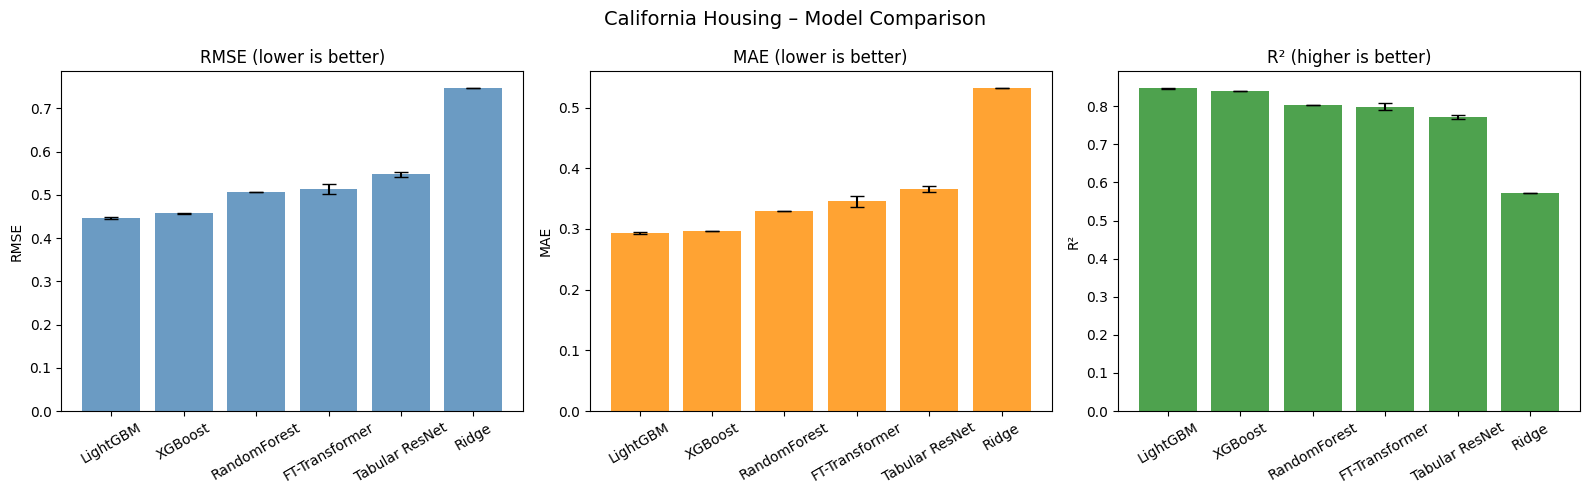

In [151]:
# RMSE, MAE, R2 visualizations
methods = summary.index.tolist()
rmse_means = summary['rmse_mean'].values
rmse_stds  = summary['rmse_std'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(methods, summary['rmse_mean'].values, yerr=summary['rmse_std'].values,
            capsize=5, color='steelblue', alpha=0.8)
axes[0].set_title('RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(methods, summary['mae_mean'].values, yerr=summary['mae_std'].values,
            capsize=5, color='darkorange', alpha=0.8)
axes[1].set_title('MAE (lower is better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(methods, summary['r2_mean'].values, yerr=summary['r2_std'].values,
            capsize=5, color='forestgreen', alpha=0.8)
axes[2].set_title('R² (higher is better)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('California Housing – Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()


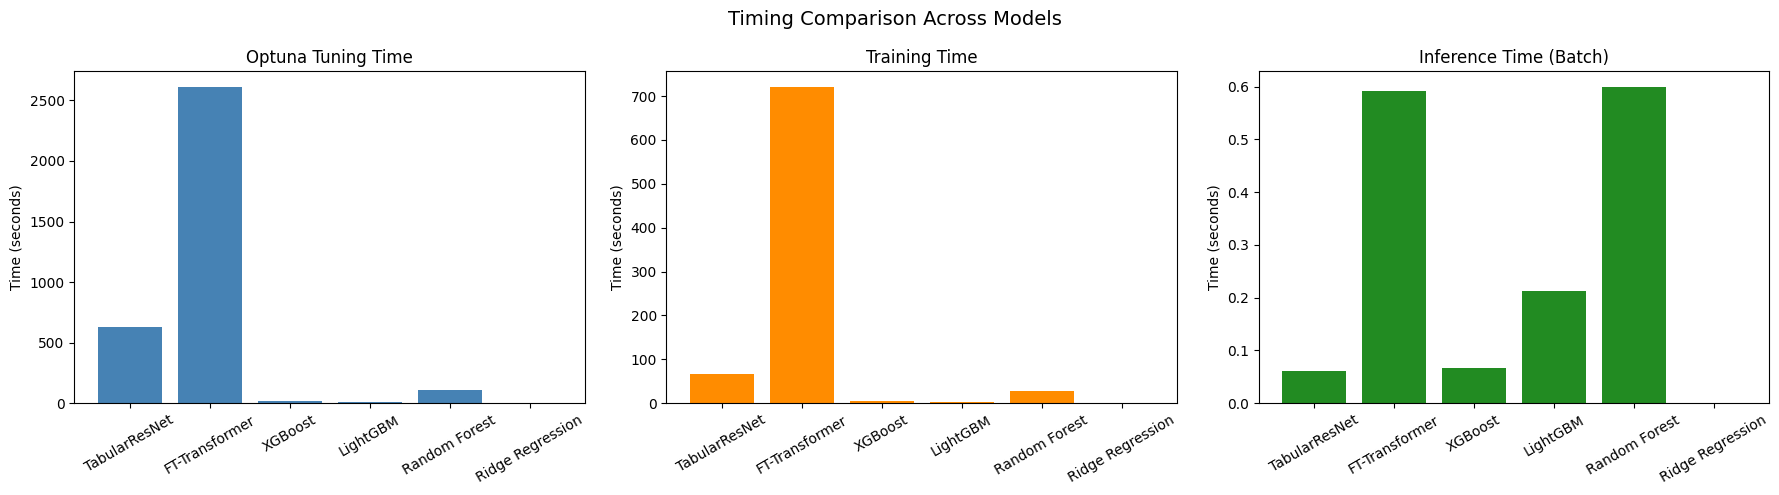

In [152]:
# Timing visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

methods = df_time_summary["method"]

# --- Optuna time ---
axes[0].bar(methods, df_time_summary["optuna_time"], color="steelblue")
axes[0].set_title("Optuna Tuning Time")
axes[0].set_ylabel("Time (seconds)")
axes[0].tick_params(axis='x', rotation=30)

# --- Training time ---
axes[1].bar(methods, df_time_summary["train_time"], color="darkorange")
axes[1].set_title("Training Time")
axes[1].set_ylabel("Time (seconds)")
axes[1].tick_params(axis='x', rotation=30)

# --- Inference time ---
axes[2].bar(methods, df_time_summary["inference_time"], color="forestgreen")
axes[2].set_title("Inference Time (Batch)")
axes[2].set_ylabel("Time (seconds)")
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle("Timing Comparison Across Models", fontsize=14)
plt.tight_layout()
plt.show()

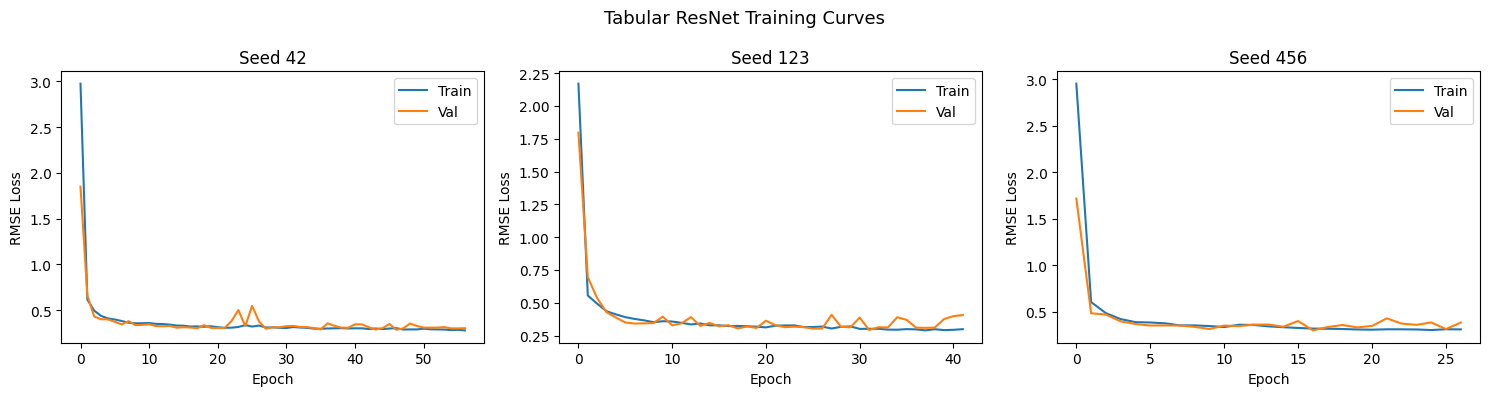

In [153]:
# Tabular Resnet training curves
fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4))

for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = resnet_train_curves[seed]
    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Val')
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('RMSE Loss')
    ax.legend()

plt.suptitle('Tabular ResNet Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

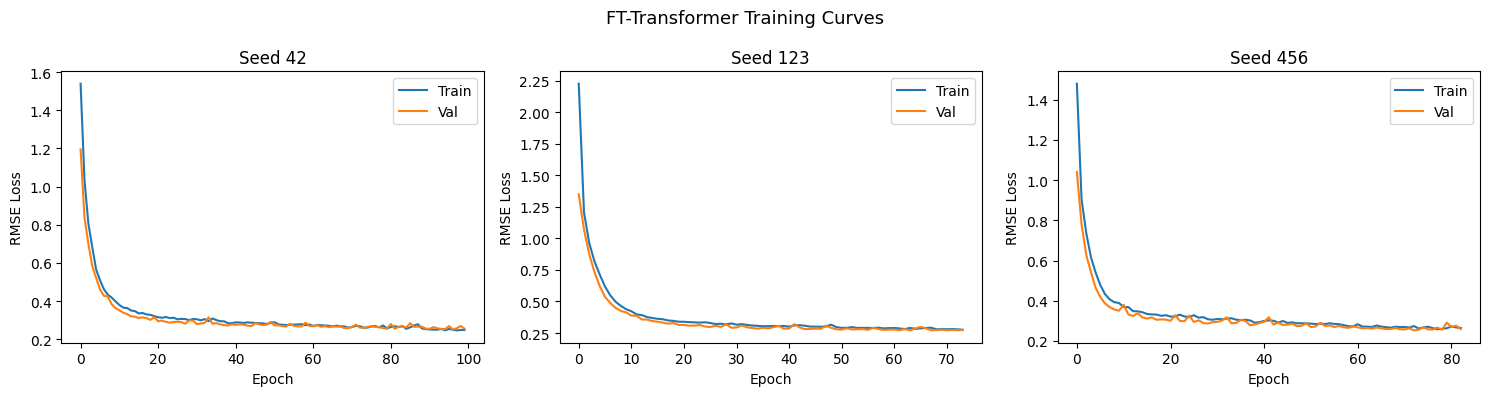

In [154]:
# FT-Transformer training curves
fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4))
for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = ft_train_curves[seed]
    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Val')
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('RMSE Loss')
    ax.legend()
plt.suptitle('FT-Transformer Training Curves', fontsize=13)
plt.tight_layout()
plt.show()


<module 'matplotlib.pyplot' from 'c:\\Users\\quah_\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages\\matplotlib\\pyplot.py'>

<Figure size 1000x600 with 0 Axes>

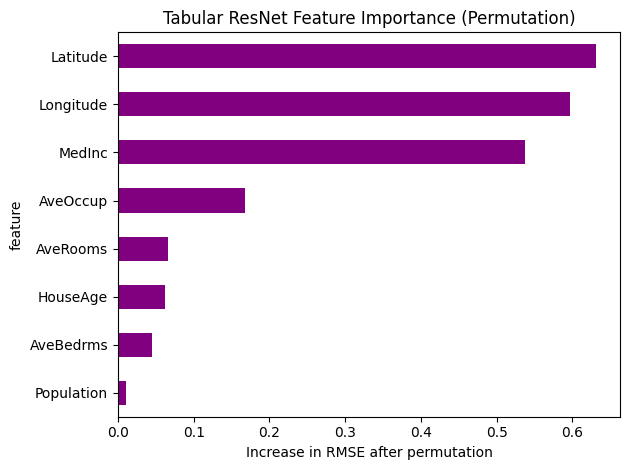

In [155]:
# Tabular ResNet feature importance via permutation importance
def resnet_permutation_importance(
    model,
    X,
    y,
    feature_names,
    device,
    n_repeats=5,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    base_preds = predict_resnet(model, X, str(device))
    base_rmse = np.sqrt(mean_squared_error(y, base_preds))

    importances = []

    for j, feat in enumerate(feature_names):
        deltas = []

        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])

            perm_preds = predict_resnet(model, X_perm, str(device))
            perm_rmse = np.sqrt(mean_squared_error(y, perm_preds))

            deltas.append(perm_rmse - base_rmse)

        importances.append({
            "feature": feat,
            "importance": np.mean(deltas),
            "std": np.std(deltas),
        })

    return pd.DataFrame(importances)

resnet_fi = resnet_permutation_importance(
    model=rn_model_last,
    X=X_test_sc,
    y=y_test,
    feature_names=feature_cols,
    device=device,
    n_repeats=5,
)
fi_all = resnet_fi.sort_values("importance")

plt.figure(figsize=(10, 6))
fi_all.plot.barh(
    x="feature",
    y="importance",
    legend=False,
    color="purple",
)
plt.title("Tabular ResNet Feature Importance (Permutation)")
plt.xlabel("Increase in RMSE after permutation")
plt.tight_layout()
plt

<Figure size 1000x600 with 0 Axes>

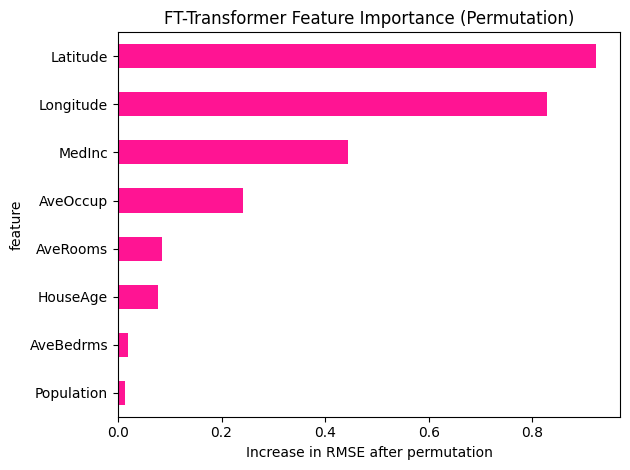

In [156]:
# FT-Transformer feature importance via permutation importance
def ft_permutation_importance(
    model,
    X,
    y,
    feature_names,
    device,
    n_repeats=5,
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    base_preds = predict_ft_transformer(
        model,
        X,
        None,                 # no categorical features
        str(device),
    )
    base_rmse = np.sqrt(mean_squared_error(y, base_preds))

    importances = []

    for j, feat in enumerate(feature_names):
        deltas = []

        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])

            perm_preds = predict_ft_transformer(
                model,
                X_perm,
                None,
                str(device),
            )
            perm_rmse = np.sqrt(mean_squared_error(y, perm_preds))

            deltas.append(perm_rmse - base_rmse)

        importances.append({
            "feature": feat,
            "importance": np.mean(deltas),
            "std": np.std(deltas),
        })

    return pd.DataFrame(importances)
ft_fi = ft_permutation_importance(
    model=ft_model_last,
    X=X_test_sc,
    y=y_test,
    feature_names=feature_cols,
    device=device,
    n_repeats=5,
)
fi_all_ft = ft_fi.sort_values("importance")

plt.figure(figsize=(10, 6))
fi_all_ft.plot.barh(
    x="feature",
    y="importance",
    legend=False,
    color="deeppink",
)
plt.title("FT-Transformer Feature Importance (Permutation)")
plt.xlabel("Increase in RMSE after permutation")
plt.tight_layout()
plt.show()

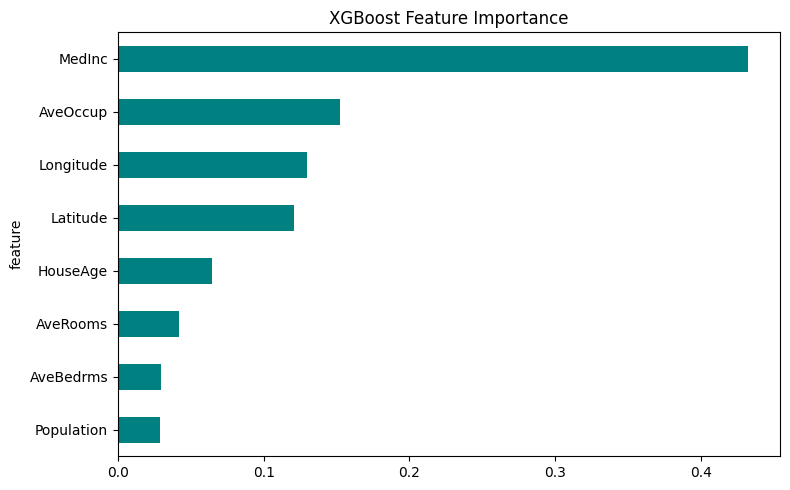

In [157]:
# XGBoost feature importance
if xgb_model_last is not None:
    fi = xgb_model_last.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': fi}).sort_values(
        'importance', ascending=True)
    fi_df.plot.barh(x='feature', y='importance', figsize=(8, 5), legend=False,
                    color='teal')
    plt.title('XGBoost Feature Importance')
    plt.tight_layout()
    plt.show()


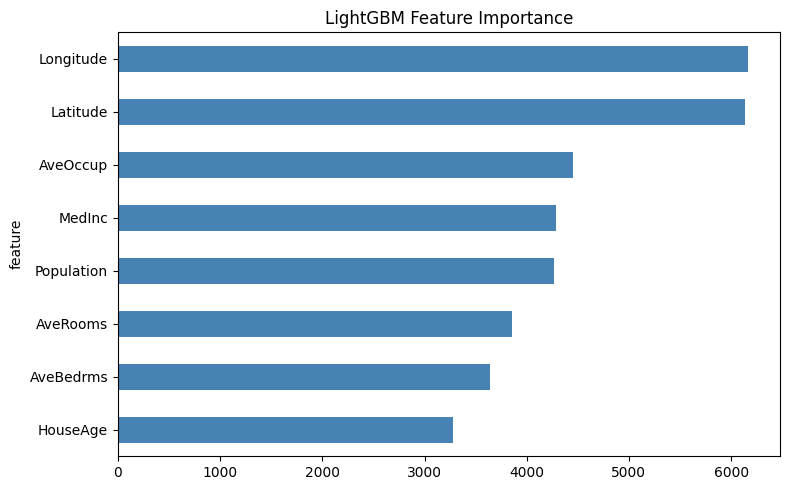

In [158]:
# LightGBM feature importance
if lgbm_model_last is not None:
    fi = lgbm_model_last.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': fi}).sort_values(
        'importance', ascending=True)
    fi_df.plot.barh(x='feature', y='importance', figsize=(8, 5), legend=False,
                    color='steelblue')
    plt.title('LightGBM Feature Importance')
    plt.tight_layout()
    plt.show()  

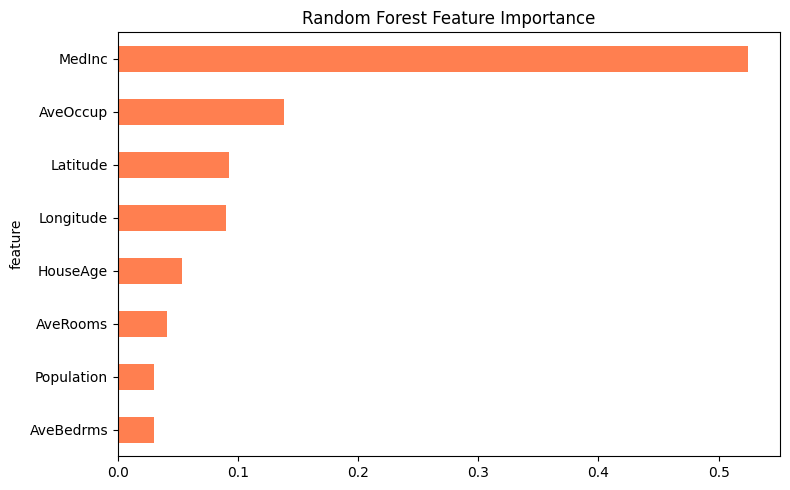

In [159]:
# Random Forest feature importance
if rf_model_last is not None:
    fi = rf_model_last.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': fi}).sort_values(
        'importance', ascending=True)
    fi_df.plot.barh(x='feature', y='importance', figsize=(8, 5), legend=False,
                    color='coral')
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    plt.show()
